# Data Overview

This notebook provides the first structured inspection of the fraud detection dataset. Its purpose is to understand dataset size, schema, data quality, and target distribution before moving into deeper exploratory analysis and model development.

## 1. Objectives

This notebook focuses on the following tasks:

- load the raw dataset using the project data loader
- review dataset shape, columns, and data types
- inspect missing values and duplicate rows
- validate the raw dataset structure
- examine the target distribution
- summarize numerical variables with emphasis on `Time` and `Amount`
- document initial observations for the next stage of EDA

In [57]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path("..").resolve()))

from src.config import NUMERICAL_COLUMNS, REPORTS_FIGURES_DIR, REPORTS_TABLES_DIR, TARGET_COLUMN
from src.data.data_loader import load_raw_data
from src.data.data_validation import DataValidationError, validate_raw_data

REPORTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Data

In [58]:
df = load_raw_data()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [59]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


## 3. Dataset Structure

In [60]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())

Number of rows: 284807
Number of columns: 31

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [62]:
schema_summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values
})
schema_summary.to_csv(REPORTS_TABLES_DIR / "dataset_schema_summary.csv", index=False)
schema_summary

,column,dtype
0,Time,float64
1,V1,float64
2,V2,float64
3,V3,float64
4,V4,float64
5,V5,float64
6,V6,float64
7,V7,float64
8,V8,float64
9,V9,float64


## 4. Data Quality Checks

In [63]:
missing_counts = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(4)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent
})

missing_summary_filtered = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing_summary.to_csv(REPORTS_TABLES_DIR / "missing_values_summary.csv")
missing_summary_filtered

,missing_count,missing_percent


In [64]:
duplicate_count = int(df.duplicated().sum())
duplicate_summary = pd.DataFrame({"metric": ["duplicate_rows"], "value": [duplicate_count]})
duplicate_summary.to_csv(REPORTS_TABLES_DIR / "duplicate_rows_summary.csv", index=False)
print("Duplicate rows:", duplicate_count)
duplicate_summary

Duplicate rows: 1081


,metric,value
0,duplicate_rows,1081


In [65]:
try:
    validate_raw_data(df)
    print("Raw data validation: PASSED")
except DataValidationError as error:
    print("Raw data validation: FAILED")
    print(error)

Raw data validation: PASSED


## 5. Target Variable Overview

In [66]:
target_counts = df[TARGET_COLUMN].value_counts().sort_index()
target_percent = (df[TARGET_COLUMN].value_counts(normalize=True).sort_index() * 100).round(4)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent
})
target_summary.index.name = TARGET_COLUMN
target_summary.to_csv(REPORTS_TABLES_DIR / "target_class_distribution.csv")
target_summary

,count,percent
Class,,
0,284315,99.8273
1,492,0.1727


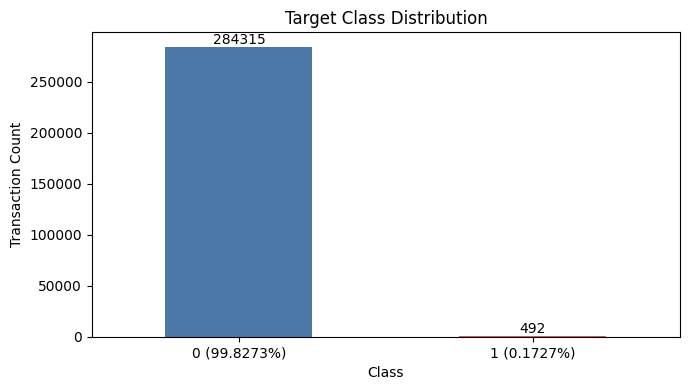

In [67]:
ax = target_counts.plot(kind="bar", color=["#4C78A8", "#E45756"], figsize=(7, 4))
ax.set_title("Target Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Transaction Count")
ax.set_xticklabels([f"{idx} ({target_percent.loc[idx]:.4f}%)" for idx in target_counts.index], rotation=0)
for i, value in enumerate(target_counts.values):
    ax.text(i, value, f"{value}", ha="center", va="bottom")
figure_path = REPORTS_FIGURES_DIR / "target_class_distribution.png"
plt.tight_layout()
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

The target distribution should be reviewed carefully because fraud detection is a highly imbalanced classification problem. A very small fraud class means evaluation metrics such as recall, precision, F1-score, and PR-AUC will be more informative than accuracy alone.

## 6. Summary Statistics

In [68]:
numerical_summary = df[NUMERICAL_COLUMNS + [TARGET_COLUMN]].describe().T
numerical_summary.to_csv(REPORTS_TABLES_DIR / "numerical_summary_statistics.csv")
numerical_summary

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [69]:
time_amount_summary = df[["Time", "Amount"]].describe().T
time_amount_summary.to_csv(REPORTS_TABLES_DIR / "time_amount_summary_statistics.csv")
time_amount_summary

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16


## 7. Initial Feature Notes

The dataset contains `Time`, `Amount`, and anonymized features `V1` to `V28`. These `V1` to `V28` variables are PCA-transformed features, which means the original feature names and meanings are not available. This improves confidentiality, but it also limits direct interpretability during EDA and later model explanation.

## 8. Initial Observations

- the dataset is large enough for meaningful fraud analysis
- the target variable is highly imbalanced, which will affect model evaluation strategy
- `Time` and `Amount` are the most directly interpretable numerical variables
- the PCA-based variables contain predictive information, but their business interpretation is limited
- data quality findings from missing values and duplicates should guide the next cleaning and EDA steps

## 9. Next Step

The next notebook should be `03_data_validation.ipynb`. It should focus on validating dataset quality in a more detailed and structured way, including schema checks, missing values, duplicate records, target integrity, numeric consistency, and any issues that must be resolved before deeper exploratory analysis or feature engineering.

In [70]:
REPORTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

eda_notes = """# EDA Report\n\n## Data Overview Observations\n\n- The dataset is large enough for meaningful fraud analysis.\n- The target variable is highly imbalanced, which will affect model evaluation strategy.\n- `Time` and `Amount` are the most directly interpretable numerical variables.\n- The PCA-based variables contain predictive information, but their business interpretation is limited.\n- Data quality findings from missing values and duplicates should guide the next cleaning and EDA steps.\n\n## Saved Tables\n\n- `reports/tables/dataset_schema_summary.csv`\n- `reports/tables/missing_values_summary.csv`\n- `reports/tables/duplicate_rows_summary.csv`\n- `reports/tables/target_class_distribution.csv`\n- `reports/tables/numerical_summary_statistics.csv`\n- `reports/tables/time_amount_summary_statistics.csv`\n\n## Saved Figures\n\n- `reports/figures/target_class_distribution.png`\n"""

report_path = Path("../reports/eda_report.md")
report_path.parent.mkdir(parents=True, exist_ok=True)
report_path.write_text(eda_notes, encoding="utf-8")
print(f"EDA notes saved to: {report_path}")

EDA notes saved to: ../reports/eda_report.md
